# Classification Modeling: Hotel Booking Cancellation

이 노트북은 전처리된 `hotel_bookings_clf.csv`를 사용해 호텔 예약 취소 여부(`is_canceled`)를 예측한다. 모델은 수업에서 다룬 기본적인 supervised learning, scikit-learn, evaluation, ensemble learning 범위 안에서 구성했다.

모델링 목표는 단순히 정확도만 높이는 것이 아니라, 취소 위험이 높은 예약을 사전에 식별할 수 있는지 확인하는 것이다.

In [1]:
# Import libraries for classification modeling
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load the Processed Classification Dataset

전처리 단계에서 결측치 처리, 이상치 일부 제거, 범주형 변수 원-핫 인코딩, 누수 컬럼 제거가 완료된 분류용 데이터를 불러온다.

In [2]:
# Load the processed classification data
data_path = '../data/processed/hotel_bookings_clf.csv'

if not os.path.exists(data_path):
    data_path = 'data/processed/hotel_bookings_clf.csv'

df = pd.read_csv(data_path)

print('Data path:', data_path)
print('Shape:', df.shape)
display(df.head())

Data path: ../data/processed/hotel_bookings_clf.csv
Shape: (119210, 83)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
0,0,342,2015,27,1,0,0,2,0.0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,737,2015,27,1,0,0,2,0.0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,7,2015,27,1,0,1,1,0.0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Check target balance and basic data quality
print('Missing values:', int(df.isnull().sum().sum()))
print('Object columns:', len(df.select_dtypes(include='object').columns))
print('\nTarget count:')
print(df['is_canceled'].value_counts().sort_index())
print('\nTarget ratio:')
print((df['is_canceled'].value_counts(normalize=True).sort_index() * 100).round(2))

Missing values: 0
Object columns: 0

Target count:
is_canceled
0    75011
1    44199
Name: count, dtype: int64

Target ratio:
is_canceled
0    62.92
1    37.08
Name: proportion, dtype: float64


## 2. Feature and Target Setup

`is_canceled`는 예측해야 하는 target이므로 입력 변수에서 제외한다. `adr`는 회귀 파트의 target이고, 제안서의 취소 예측 후보 변수에도 직접 포함되지 않았기 때문에 분류 입력에서 제외했다. 또한 `assigned_room_type_*`는 실제 운영 상황에서 예약 시점에 확정되지 않을 수 있으므로 누수 위험을 줄이기 위해 제외했다.

In [4]:
# Prepare X and y for cancellation prediction
target = 'is_canceled'
assigned_cols = [col for col in df.columns if col.startswith('assigned_room_type_')]
drop_cols = [target, 'adr'] + assigned_cols

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target]

print('Target:', target)
print('Dropped columns:', len(drop_cols))
print('Assigned room columns removed:', len(assigned_cols))
print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Target: is_canceled
Dropped columns: 12
Assigned room columns removed: 10
Feature shape: (119210, 71)
Target shape: (119210,)


## 3. Train/Test Split

취소 데이터는 0과 1의 비율이 완전히 같지는 않으므로 `stratify=y`를 사용했다. 이렇게 하면 train/test set에서 취소 비율이 원본 데이터와 비슷하게 유지된다.

In [5]:
# Split the data while keeping the target ratio stable
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain target ratio:')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print('\nTest target ratio:')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Train shape: (95368, 71)
Test shape: (23842, 71)

Train target ratio:
is_canceled
0    62.92
1    37.08
Name: proportion, dtype: float64

Test target ratio:
is_canceled
0    62.92
1    37.08
Name: proportion, dtype: float64


## 4. Model Candidates

비교 모델은 세 가지로 구성했다.

- Logistic Regression: 단순하고 해석 가능한 baseline
- Decision Tree: 비선형 규칙을 학습할 수 있는 기본 분류 모델
- Random Forest: 여러 tree를 결합하는 ensemble 모델

Logistic Regression은 scale 영향을 받을 수 있으므로 `StandardScaler`를 `Pipeline` 안에 넣었다. 이 방식은 cross validation 과정에서도 train fold에만 scaler가 fit되므로 data leakage를 막는다.

In [6]:
# Build simple classification models from the course scope
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1']

print('Models:', list(models.keys()))
print('CV:', cv)

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest']
CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [7]:
# Compare models with 5-fold cross validation on the training data
cv_rows = []

for name, model in models.items():
    print('Running:', name)
    score = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    cv_rows.append({
        'model': name,
        'cv_accuracy': score['test_accuracy'].mean(),
        'cv_precision': score['test_precision'].mean(),
        'cv_recall': score['test_recall'].mean(),
        'cv_f1': score['test_f1'].mean()
    })

cv_result = pd.DataFrame(cv_rows).sort_values('cv_f1', ascending=False)
display(cv_result.round(4))

Running: Logistic Regression


Running: Decision Tree


Running: Random Forest


,model,cv_accuracy,cv_precision,cv_recall,cv_f1
1,Decision Tree,0.8401,0.8142,0.7371,0.7737
2,Random Forest,0.8477,0.8645,0.6989,0.7729
0,Logistic Regression,0.8075,0.8029,0.6373,0.7105


## 5. Final Test Evaluation

최종 모델은 cross validation의 F1-score가 가장 높은 모델로 선택했다. 취소 예측 문제에서는 취소 고객을 놓치지 않는 recall도 중요하지만, 너무 많은 정상 예약을 취소 위험으로 판단하면 운영 부담이 커진다. 그래서 precision과 recall의 균형을 보는 F1-score를 기준으로 사용했다.

In [8]:
# Train the best model and evaluate it on the test data
best_name = cv_result.iloc[0]['model']
best_model = models[best_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

test_result = pd.DataFrame([{
    'model': best_name,
    'test_accuracy': accuracy_score(y_test, y_pred),
    'test_precision': precision_score(y_test, y_pred),
    'test_recall': recall_score(y_test, y_pred),
    'test_f1': f1_score(y_test, y_pred)
}])

print('Best model:', best_name)
display(test_result.round(4))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Not canceled', 'Canceled']))

Best model: Decision Tree


,model,test_accuracy,test_precision,test_recall,test_f1
0,Decision Tree,0.8399,0.8095,0.7431,0.7749



Classification report:
              precision    recall  f1-score   support

Not canceled       0.86      0.90      0.88     15002
    Canceled       0.81      0.74      0.77      8840

    accuracy                           0.84     23842
   macro avg       0.83      0.82      0.83     23842
weighted avg       0.84      0.84      0.84     23842



,Predicted not canceled,Predicted canceled
Actual not canceled,13456,1546
Actual canceled,2271,6569


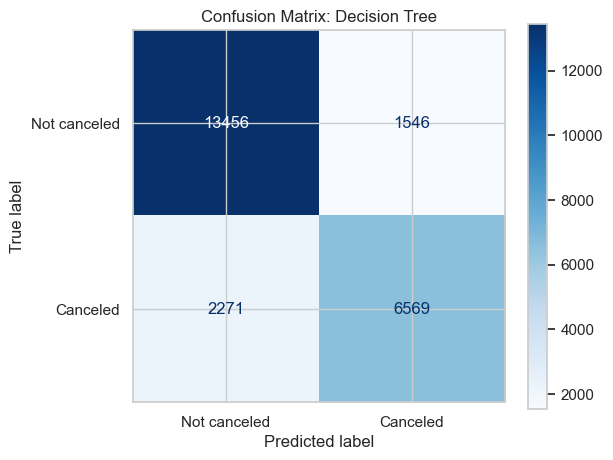

In [9]:
# Display the confusion matrix for the selected model
cm = confusion_matrix(y_test, y_pred)
cm_table = pd.DataFrame(
    cm,
    index=['Actual not canceled', 'Actual canceled'],
    columns=['Predicted not canceled', 'Predicted canceled']
)

display(cm_table)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not canceled', 'Canceled'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title(f'Confusion Matrix: {best_name}')
plt.show()

## 6. Feature Interpretation

최종 선택 모델이 tree 계열이면 feature importance를 확인하고, Logistic Regression이면 표준화된 coefficient 크기를 확인한다. 이 결과는 발표에서 어떤 예약 특성이 취소 예측에 많이 사용되었는지 설명하는 근거로 활용할 수 있다.

,feature,importance
37,deposit_type_Non Refund,0.4300
31,market_segment_Online TA,0.1117
15,total_of_special_requests,0.0896
62,country_PRT,0.0759
0,lead_time,0.0750
14,required_car_parking_spaces,0.0413
10,previous_cancellations,0.0384
1,arrival_date_year,0.0351
12,booking_changes,0.0188
40,customer_type_Transient,0.0133


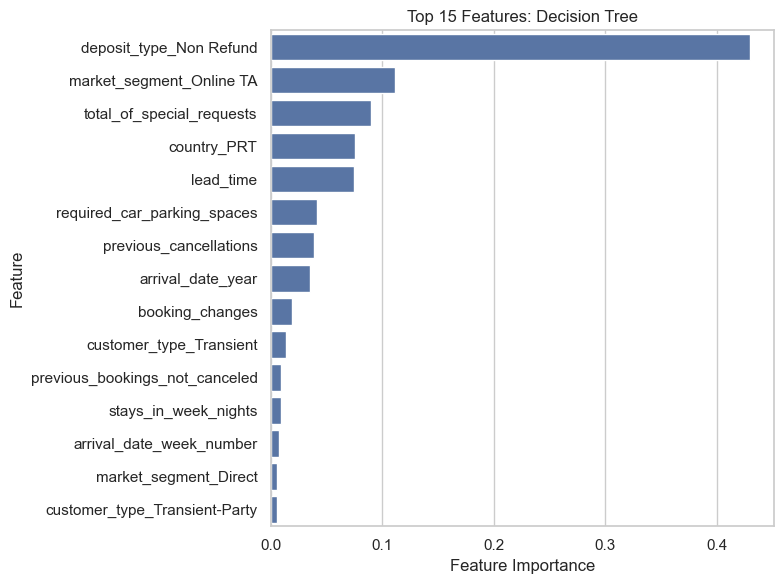

In [10]:
# Show important features from the selected model
model_part = best_model.named_steps['model'] if hasattr(best_model, 'named_steps') else best_model

if hasattr(model_part, 'feature_importances_'):
    importance = model_part.feature_importances_
    title = 'Feature Importance'
elif hasattr(model_part, 'coef_'):
    importance = np.abs(model_part.coef_[0])
    title = 'Absolute Coefficient'
else:
    importance = np.zeros(len(X.columns))
    title = 'Importance'

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values('importance', ascending=False).head(15)

display(imp_df.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set_title(f'Top 15 Features: {best_name}')
ax.set_xlabel(title)
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [11]:
# Summarize the final classification result
print('Final selected model:', best_name)
print('Number of input features:', X.shape[1])
print('Excluded adr:', 'adr' in drop_cols)
print('Excluded assigned_room_type columns:', len(assigned_cols))
print('\nTest scores:')
print(test_result.round(4).to_string(index=False))
print('\nConfusion matrix:')
print(cm_table.to_string())

Final selected model: Decision Tree
Number of input features: 71
Excluded adr: True
Excluded assigned_room_type columns: 10

Test scores:
        model  test_accuracy  test_precision  test_recall  test_f1
Decision Tree         0.8399          0.8095       0.7431   0.7749

Confusion matrix:
                     Predicted not canceled  Predicted canceled
Actual not canceled                   13456                1546
Actual canceled                        2271                6569


## Modeling Conclusion

이 노트북은 전처리 단계에서 생성한 분류용 데이터를 이용해 예약 취소 예측 모델을 비교했다. 최종 선택은 5-fold cross validation의 F1-score를 기준으로 했고, 선택된 모델은 hold-out test set에서 accuracy, precision, recall, F1-score, confusion matrix로 다시 평가했다.

이 결과는 보고서와 발표에서 "취소 위험 예약을 얼마나 잘 찾아내는가"와 "잘못 위험으로 판단하는 예약이 얼마나 있는가"를 함께 설명하는 근거로 사용할 수 있다.